# Fast-BOCPD Quickstart

Welcome! This notebook shows how to detect changepoints with the C-accelerated
``fast_bocpd`` package in just a few cells. You will:

- Create a synthetic time series with abrupt mean shifts.
- Configure an observation model (Gaussian) and hazard function.
- Stream observations through ``BOCPD`` and visualise the changepoint probability.


## 0. Environment setup

Run this notebook from the repository root (``jupyter lab``) so the relative
imports resolve. The cell below ensures the repo and ``examples`` directory are
on ``sys.path`` when working interactively.


In [1]:

import sys
from pathlib import Path

CWD = Path.cwd()
REPO_ROOT = CWD if (CWD / "fast_bocpd").exists() else CWD.parent
EXAMPLES_DIR = REPO_ROOT / "examples"

sys.path.append(str(REPO_ROOT))
sys.path.append(str(EXAMPLES_DIR))
print(f"Using repo root: {REPO_ROOT}")


Using repo root: /home/tiaan/Projects/Fast_BOCPD


## 1. Imports

``_helpers`` contains small plotting utilities shared across notebooks.


In [2]:

import numpy as np
import pandas as pd

from fast_bocpd import BOCPD, ConstantHazard, GaussianNIG

from _helpers import generate_piecewise_gaussian, plot_series_with_cp


## 2. Create a toy dataset

We'll use three regimes with different means. ``generate_piecewise_gaussian``
returns a pandas DataFrame and the ground-truth changepoint indices.


In [3]:

df, changepoints = generate_piecewise_gaussian(
    lengths=[80, 120, 70, 130],
    means=[0.0, 1.0, -0.4, 0.8],
    sigma=0.25,
    seed=7,
)
df.head()


,t,value,true_mean
0,0,0.422631,0.0
1,1,-0.116484,0.0
2,2,0.008205,0.0
3,3,0.101879,0.0
4,4,-0.197231,0.0


## 3. Configure BOCPD

- ``GaussianNIG`` models continuous data with unknown mean/variance.
- ``ConstantHazard(lambda_=120)`` says we expect a changepoint roughly every 120 samples.
- ``max_run_length`` defines how far back (in observations) we retain statistics.


In [4]:

obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=0.1, beta0=0.01)
hazard = ConstantHazard(lambda_=120)
bocpd = BOCPD(obs_model, hazard, max_run_length=400)


## 4. Stream the data

We pass each observation to ``BOCPD.update`` and store:

- ``cp_prob`` – the probability that a changepoint occurred at this step.
- ``map_run_length`` – the most likely run length (helpful for interpreting regime duration).


In [5]:

cp_probs = []
map_run_lengths = []

for value in df["value"]:
    posterior, cp_prob = bocpd.update(float(value))
    cp_probs.append(cp_prob)
    map_run_lengths.append(int(np.argmax(posterior)))

df["cp_prob"] = cp_probs
df["map_r"] = map_run_lengths
df.head()


,t,value,true_mean,cp_prob,map_r
0,0,0.422631,0.0,0.008333,1
1,1,-0.116484,0.0,0.006054,2
2,2,0.008205,0.0,0.003613,3
3,3,0.101879,0.0,0.002371,4
4,4,-0.197231,0.0,0.003296,5


## 5. Visualise detections

The plot shows both the raw signal (left axis) and the changepoint probability (right axis).
Grey dashed lines mark the ground-truth changepoints we injected into the synthetic data.


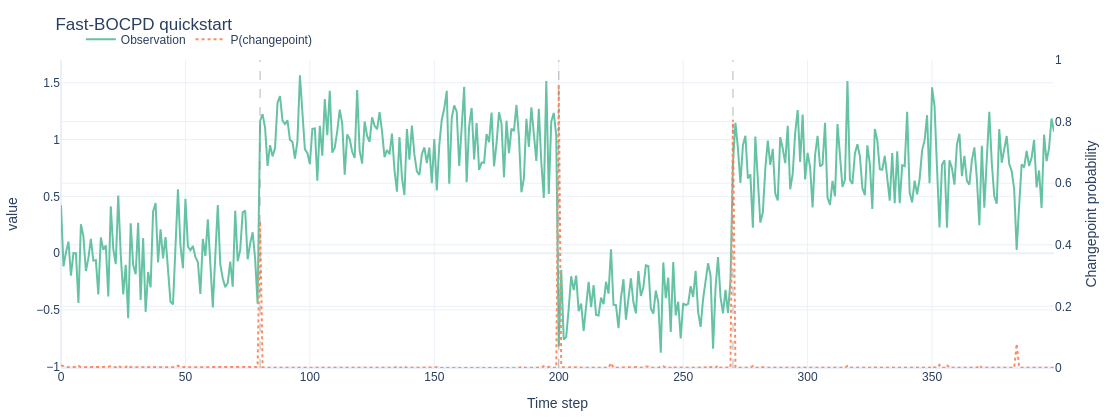

In [6]:

plot_series_with_cp(
    df,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=changepoints,
    title="Fast-BOCPD quickstart",
)


## 6. Simple alarm logic

In practice you can combine ``cp_prob`` and the MAP run length to decide when to raise an alert.
Here we trigger whenever ``P(changepoint)`` exceeds ``0.35`` *and* the MAP run length resets.


In [7]:

THRESHOLD = 0.35
alerts = df.index[(df["cp_prob"] >= THRESHOLD) & (df["map_r"] <= 2)]
alerts.tolist()


[80, 200, 270]

## Next steps

- Explore docs: `user_guide/choosing_model` to pick the best observation model for your data.
- Continue with ``02_online_vs_batch.ipynb`` to learn how offline/batch updates accelerate processing.
- Inspect the ``examples`` directory README for instructions on running the rest of the notebooks.
